# Qwen3-0.6B full-FT SFT: train+val -> test, SID-v2, window 16

Final full fine-tuning run after validation selection. Train source is train+val; test is evaluated once after training with all-history seen filtering.


## 1. Imports and config

Use `DRY_RUN_STEPS = 1` only for a smoke test. For the real run keep `DRY_RUN_STEPS = 0`.


In [1]:
from pathlib import Path
from importlib import metadata
from packaging.version import Version
import inspect
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from tqdm.auto import tqdm

from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments

os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

RUN_NAME = os.environ.get("SFT_RUN_NAME", "sft_qwen3_0_6b_fullft_cpt_fullft_sid_v2_trainval_test_w16_e7_allseen_v1")
BASE_CPT_DIR = ROOT / os.environ.get("SFT_BASE_CPT_DIR", "data/processed/artifacts/cpt_qwen3_0_6b_base_sid_v2_plum_curriculum_full_ft_v1/final_model")
SID_ARRAY_PATH = ROOT / "runs/qwen4b_rqvae_sid_v2_plum/SIDs_best.npy"
TRAIN_PATH = ROOT / "data/processed/splits/train.parquet"
VAL_PATH = ROOT / "data/processed/splits/val.parquet"
TEST_PATH = ROOT / "data/processed/splits/test.parquet"
USERS_PATH = ROOT / "data/raw/ml-1m/users.dat"

OUTPUT_DIR = ROOT / "data/processed/artifacts" / RUN_NAME
TMP_TRAINER_DIR = OUTPUT_DIR / "trainer_tmp"
FINAL_MODEL_DIR = OUTPUT_DIR / "final_model"
SEED = 42
MAX_EPOCHS = int(os.environ.get("SFT_MAX_EPOCHS", "7"))
PRIMARY_METRIC = "recall@10"
SELECTED_EPOCHS_FROM_VALIDATION = 7

MIN_HISTORY_LEN = 16
TRAIN_HISTORY_WINDOW_CHOICES = [16]
EVAL_HISTORY_LEN = 16
TARGETS_PER_USER_PER_EPOCH = 4
RECENT_TARGET_FRACTION = 0.65
INCLUDE_RATINGS = True
INCLUDE_USER_FEATURES = True
FILTER_SEEN = True
SEEN_FILTER_SCOPE = "all_history"

MAX_SEQ_LENGTH = 192
MAX_TARGET_TOKENS = 8
TOP_K = 10
EVAL_BEAM_SIZE = 20
EVAL_NUM_RETURN_SEQUENCES = 20
FULL_TEST_MAX_USERS = None
RUN_FINAL_FULL_TEST = False

LEARNING_RATE = float(os.environ.get("SFT_LEARNING_RATE", "5e-5"))
WARMUP_RATIO = 0.03
WEIGHT_DECAY = 0.01
PER_DEVICE_BATCH = int(os.environ.get("SFT_PER_DEVICE_BATCH", "4"))
GRADIENT_ACCUMULATION_STEPS = int(os.environ.get("SFT_GRADIENT_ACCUMULATION_STEPS", "16"))
LOGGING_STEPS = 20
DRY_RUN_STEPS = int(os.environ.get("SFT_DRY_RUN_STEPS", "0"))

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BF16 = DEVICE == "cuda" and torch.cuda.is_bf16_supported()
FP16 = DEVICE == "cuda" and not BF16
DTYPE = torch.bfloat16 if BF16 else (torch.float16 if FP16 else torch.float32)
PRECISION_MODE = "bf16" if BF16 else ("fp16" if FP16 else "fp32")

if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.cuda.empty_cache()

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("root:", ROOT)
print("base CPT:", BASE_CPT_DIR)
print("device:", DEVICE, PRECISION_MODE)
print("effective batch:", PER_DEVICE_BATCH * GRADIENT_ACCUMULATION_STEPS)
print("full fine-tune:", True)

root: C:\Users\User\plum-ml1m-repro
base CPT: C:\Users\User\plum-ml1m-repro\data\processed\artifacts\cpt_qwen3_0_6b_base_sid_v2_plum_curriculum_full_ft_v1\final_model
device: cuda bf16
effective batch: 64
full fine-tune: True


## 2. Load data

SFT training uses only train interactions. Validation target is `val.parquet`; test is not used here.


In [2]:
assert BASE_CPT_DIR.exists(), BASE_CPT_DIR
train = pd.read_parquet(TRAIN_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").reset_index(drop=True)
val = pd.read_parquet(VAL_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").reset_index(drop=True)
test = pd.read_parquet(TEST_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").reset_index(drop=True)
users = pd.read_csv(
    USERS_PATH,
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip"],
    encoding="latin-1",
)
sids = np.load(SID_ARRAY_PATH)

print("train/val/test:", len(train), len(val), len(test))
print("users:", len(users), "items:", len(sids))
train.head()

train/val/test: 988129 6040 6040
users: 6040 items: 3706


,user_id,movie_id,rating,timestamp,user_idx,item_idx,pos,len
0,1,3186,4,978300019,0,2969,0,53
1,1,1270,5,978300055,0,1178,1,53
2,1,1721,4,978300055,0,1574,2,53
3,1,1022,5,978300055,0,957,3,53
4,1,2340,3,978300103,0,2147,4,53


## 3. Tokenizer, SID tokens, and collision suffixes

SID collisions are rare, but suffixes keep target sequences item-level unique.

In [3]:
BOS = "<bos>"
EOS = "<eos>"
PAD = "<pad>"
USER_OPEN = "<user>"
USER_CLOSE = "</user>"
HIST = "<hist>"
EVENT_OPEN = "<e>"
EVENT_CLOSE = "</e>"
TASK_REC = "<task_rec>"
NEXT = "<next>"


def base_sid_tokens(sid):
    return [f"<sid_{level}_{int(code)}>" for level, code in enumerate(sid)]


def rating_token(rating):
    return f"<rat_{int(rating)}>"


def user_tokens(row):
    return [f"<gen_{row.gender}>", f"<age_{int(row.age)}>", f"<occ_{int(row.occupation)}>"]

sid_keys = [tuple(int(x) for x in sid) for sid in sids]
sid_to_items = {}
for item_idx, key in enumerate(sid_keys):
    sid_to_items.setdefault(key, []).append(int(item_idx))

item_dup_suffix = {}
dup_tokens = []
for key, items in sid_to_items.items():
    if len(items) > 1:
        for dup_i, item_idx in enumerate(sorted(items)):
            tok = f"<dup_{dup_i}>"
            item_dup_suffix[int(item_idx)] = tok
            dup_tokens.append(tok)

def item_sid_tokens(item_idx):
    tokens = base_sid_tokens(sids[int(item_idx)])
    if int(item_idx) in item_dup_suffix:
        tokens = tokens + [item_dup_suffix[int(item_idx)]]
    return tokens


def load_tokenizer(path):
    try:
        return AutoTokenizer.from_pretrained(path, use_fast=True, fix_mistral_regex=True, local_files_only=True)
    except TypeError:
        return AutoTokenizer.from_pretrained(path, use_fast=True, local_files_only=True)


tokenizer = load_tokenizer(BASE_CPT_DIR)
base_vocab_size = len(tokenizer)
extra_tokens = [TASK_REC, NEXT, *sorted(set(dup_tokens))]
added = tokenizer.add_tokens([tok for tok in extra_tokens if tok not in tokenizer.get_vocab()], special_tokens=True)
new_token_ids = sorted(set(int(x) for x in tokenizer.convert_tokens_to_ids(extra_tokens)))

print("base vocab:", base_vocab_size, "current vocab:", len(tokenizer), "added:", added)
print("SID collisions:", sum(len(v) > 1 for v in sid_to_items.values()), "dup items:", len(item_dup_suffix))
print("new token ids:", len(new_token_ids))

base vocab: 152053 current vocab: 152057 added: 4
SID collisions: 11 dup items: 22
new token ids: 4


## 4. Build trie and item maps

The trie constrains generation to valid item token sequences only.

In [4]:
def token_ids_for_item(item_idx):
    return tuple(int(x) for x in tokenizer.convert_tokens_to_ids(item_sid_tokens(item_idx)))

item_to_token_ids = {int(i): token_ids_for_item(i) for i in range(len(sids))}
token_ids_to_item = {v: k for k, v in item_to_token_ids.items()}
assert len(token_ids_to_item) == len(item_to_token_ids)

TRIE = {}
for ids in item_to_token_ids.values():
    node = TRIE
    for token_id in ids:
        node = node.setdefault(int(token_id), {})
    node[int(tokenizer.eos_token_id)] = {}

EOS_ID = int(tokenizer.eos_token_id)
PAD_ID = int(tokenizer.pad_token_id)
print("valid item sequences:", len(item_to_token_ids))
print("max target tokens:", max(len(x) for x in item_to_token_ids.values()) + 1)

valid item sequences: 3706
max target tokens: 6


## 5. Prompt and example encoding

In [5]:
users_by_id = users.set_index("user_id", drop=False)

train_events_by_user = {
    int(user_id): group.sort_values(["timestamp", "pos", "item_idx"], kind="mergesort").to_dict("records")
    for user_id, group in train.groupby("user_id", sort=False)
}

val_target_by_user = {
    int(row.user_id): row._asdict()
    for row in val.sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").itertuples(index=False)
}

test_target_by_user = {
    int(row.user_id): row._asdict()
    for row in test.sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").itertuples(index=False)
}

train_plus_val_events_by_user = {
    int(user_id): group.sort_values(["timestamp", "pos", "item_idx"], kind="mergesort").to_dict("records")
    for user_id, group in pd.concat([train, val], ignore_index=True).groupby("user_id", sort=False)
}


def event_tokens(event):
    tokens = [EVENT_OPEN]
    tokens.extend(item_sid_tokens(event["item_idx"]))
    if INCLUDE_RATINGS:
        tokens.append(rating_token(event["rating"]))
    tokens.append(EVENT_CLOSE)
    return tokens


def prompt_prefix_tokens(user_id):
    tokens = [BOS, TASK_REC]
    if INCLUDE_USER_FEATURES and int(user_id) in users_by_id.index:
        tokens.append(USER_OPEN)
        tokens.extend(user_tokens(users_by_id.loc[int(user_id)]))
        tokens.append(USER_CLOSE)
    tokens.append(HIST)
    return tokens


def fit_prompt(prefix, history_events, target_tokens):
    event_blocks = [event_tokens(event) for event in history_events]
    while event_blocks:
        prompt_tokens = prefix + [tok for block in event_blocks for tok in block] + [NEXT]
        if len(prompt_tokens) + len(target_tokens) <= MAX_SEQ_LENGTH:
            return prompt_tokens
        event_blocks = event_blocks[1:]
    prompt_tokens = prefix + [NEXT]
    if len(prompt_tokens) + len(target_tokens) > MAX_SEQ_LENGTH:
        raise ValueError("Prompt prefix plus target exceeds MAX_SEQ_LENGTH")
    return prompt_tokens


def encode_sft_example(user_id, history_events, target_event, split, seen_events=None):
    seen_events = history_events if seen_events is None else seen_events
    target_item = int(target_event["item_idx"])
    target_tokens = item_sid_tokens(target_item) + [EOS]
    prompt_tokens = fit_prompt(prompt_prefix_tokens(user_id), history_events, target_tokens)
    all_tokens = prompt_tokens + target_tokens
    input_ids = tokenizer.convert_tokens_to_ids(all_tokens)
    labels = [-100] * len(prompt_tokens) + input_ids[len(prompt_tokens):]

    if any(token_id == tokenizer.unk_token_id for token_id in input_ids):
        bad = [tok for tok, token_id in zip(all_tokens, input_ids) if token_id == tokenizer.unk_token_id]
        raise ValueError(f"Unknown tokens: {bad[:10]}")

    return {
        "input_ids": input_ids,
        "labels": labels,
        "prompt_length": len(prompt_tokens),
        "user_id": int(user_id),
        "split": split,
        "target_item_idx": target_item,
        "history_item_idx": [int(event["item_idx"]) for event in history_events],
        "all_seen_item_idx": [int(event["item_idx"]) for event in seen_events],
    }

## 6. Dynamic train sampler

Each epoch resamples target positions. Every example uses exactly 16 history events.


In [6]:
def sample_target_positions(n_events, rng):
    valid = np.arange(MIN_HISTORY_LEN, n_events, dtype=np.int32)
    if len(valid) == 0:
        return []

    n_recent = int(round(TARGETS_PER_USER_PER_EPOCH * RECENT_TARGET_FRACTION))
    n_random = TARGETS_PER_USER_PER_EPOCH - n_recent
    recent_pool_start = max(MIN_HISTORY_LEN, int(n_events * 0.70))
    recent_pool = np.arange(recent_pool_start, n_events, dtype=np.int32)
    if len(recent_pool) == 0:
        recent_pool = valid

    recent = rng.choice(recent_pool, size=min(n_recent, len(recent_pool)), replace=len(recent_pool) < n_recent)
    random_pos = rng.choice(valid, size=min(n_random, len(valid)), replace=len(valid) < n_random)
    return sorted(set(int(x) for x in np.concatenate([recent, random_pos])))


def build_train_examples_for_epoch(epoch):
    rng = np.random.default_rng(SEED + epoch)
    examples = []
    stats = []

    for user_id, events in train_plus_val_events_by_user.items():
        positions = sample_target_positions(len(events), rng)
        for target_pos in positions:
            target_event = events[target_pos]
            window = int(rng.choice(TRAIN_HISTORY_WINDOW_CHOICES))
            start = max(0, target_pos - window)
            history_events = events[start:target_pos]
            if len(history_events) < MIN_HISTORY_LEN:
                continue
            ex = encode_sft_example(user_id, history_events, target_event, split="trainval")
            examples.append(ex)
            stats.append((len(history_events), len(ex["input_ids"])))

    rng.shuffle(examples)
    stats = np.array(stats, dtype=np.int32) if stats else np.zeros((0, 2), dtype=np.int32)
    epoch_stats = {
        "epoch": int(epoch),
        "examples": int(len(examples)),
        "history_p50": int(np.percentile(stats[:, 0], 50)) if len(stats) else 0,
        "history_p95": int(np.percentile(stats[:, 0], 95)) if len(stats) else 0,
        "length_p50": int(np.percentile(stats[:, 1], 50)) if len(stats) else 0,
        "length_p95": int(np.percentile(stats[:, 1], 95)) if len(stats) else 0,
        "length_max": int(stats[:, 1].max()) if len(stats) else 0,
    }
    return examples, epoch_stats

train_preview, train_preview_stats = build_train_examples_for_epoch(0)
train_preview_stats

{'epoch': 0,
 'examples': 23485,
 'history_p50': 16,
 'history_p95': 16,
 'length_p50': 126,
 'length_p95': 126,
 'length_max': 130}

## 7. Test examples

In [7]:
def build_eval_examples(split="test", max_users=None, seed=SEED):
    if split == "test":
        context_by_user = train_plus_val_events_by_user
        target_by_user = test_target_by_user
    else:
        raise ValueError("split must be 'test'")

    user_ids = sorted(target_by_user.keys())
    if max_users is not None:
        rng = np.random.default_rng(seed)
        user_ids = sorted(rng.choice(user_ids, size=min(max_users, len(user_ids)), replace=False).tolist())

    examples = []
    for user_id in user_ids:
        full_history = context_by_user.get(int(user_id), [])
        history = full_history[-EVAL_HISTORY_LEN:]
        if len(history) < MIN_HISTORY_LEN:
            continue
        examples.append(encode_sft_example(user_id, history, target_by_user[user_id], split=split, seen_events=full_history))
    return examples

full_test_examples = build_eval_examples("test", max_users=FULL_TEST_MAX_USERS)
print("full test examples:", len(full_test_examples))


full test examples: 6040


## 8. Dataset and collator

In [8]:
class SFTListDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        return {"input_ids": ex["input_ids"], "labels": ex["labels"]}


class SFTCollator:
    def __init__(self, tokenizer, pad_to_multiple_of=8):
        self.tokenizer = tokenizer
        self.pad_to_multiple_of = pad_to_multiple_of

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)
        if self.pad_to_multiple_of:
            max_len = int(math.ceil(max_len / self.pad_to_multiple_of) * self.pad_to_multiple_of)

        input_ids, labels, attention_mask = [], [], []
        for f in features:
            ids = list(f["input_ids"])
            lab = list(f["labels"])
            pad_len = max_len - len(ids)
            input_ids.append(ids + [self.tokenizer.pad_token_id] * pad_len)
            labels.append(lab + [-100] * pad_len)
            attention_mask.append([1] * len(ids) + [0] * pad_len)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
        }

collator = SFTCollator(tokenizer)

## 9. Load full-FT CPT model

In [9]:
def load_causal_lm(path):
    kwargs = {
        "torch_dtype": DTYPE,
        "local_files_only": True,
        "trust_remote_code": False,
        "low_cpu_mem_usage": True,
    }
    try:
        model = AutoModelForCausalLM.from_pretrained(path, attn_implementation="sdpa", **kwargs)
    except TypeError:
        model = AutoModelForCausalLM.from_pretrained(path, **kwargs)
    return model

model = load_causal_lm(BASE_CPT_DIR)
model.resize_token_embeddings(len(tokenizer), mean_resizing=False)
model.config.bos_token_id = tokenizer.bos_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False
model.to(DEVICE)

if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print({"trainable_params": trainable_params, "total_params": total_params, "trainable_pct": 100 * trainable_params / total_params})


`torch_dtype` is deprecated! Use `dtype` instead!


{'trainable_params': 596173824, 'total_params': 596173824, 'trainable_pct': 100.0}


## 10. Trie decoding and metrics

In [10]:
def set_generation_mode(model):
    model.eval()
    model.config.use_cache = True
    if hasattr(model, "gradient_checkpointing_disable"):
        model.gradient_checkpointing_disable()
    torch.cuda.empty_cache() if DEVICE == "cuda" else None


def set_training_mode(model):
    model.train()
    model.config.use_cache = False
    if hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})


def trie_allowed_tokens(prompt_length):
    def allowed(_batch_id, input_ids):
        node = TRIE
        generated = input_ids[prompt_length:].tolist()
        for token_id in generated:
            token_id = int(token_id)
            if token_id not in node:
                return [EOS_ID]
            node = node[token_id]
        return sorted(node.keys()) if node else [EOS_ID]
    return allowed


def decode_generated_item(sequence_ids, prompt_length):
    new_ids = []
    for token_id in sequence_ids[prompt_length:].tolist():
        token_id = int(token_id)
        if token_id in {EOS_ID, PAD_ID}:
            break
        new_ids.append(token_id)
    return token_ids_to_item.get(tuple(new_ids))


def generate_candidates(model, example, beam_size=EVAL_BEAM_SIZE, top_k=TOP_K, num_return_sequences=EVAL_NUM_RETURN_SEQUENCES, filter_seen=FILTER_SEEN):
    prompt_ids = example["input_ids"][:example["prompt_length"]]
    input_ids = torch.tensor([prompt_ids], dtype=torch.long, device=DEVICE)
    attention_mask = torch.ones_like(input_ids)
    seen_field = "all_seen_item_idx" if SEEN_FILTER_SCOPE == "all_history" else "history_item_idx"
    seen = set(example.get(seen_field, [])) if filter_seen else set()
    num_return_sequences = min(int(num_return_sequences), int(beam_size))

    with torch.inference_mode():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_TARGET_TOKENS,
            num_beams=beam_size,
            num_return_sequences=num_return_sequences,
            do_sample=False,
            early_stopping=True,
            pad_token_id=PAD_ID,
            eos_token_id=EOS_ID,
            prefix_allowed_tokens_fn=trie_allowed_tokens(len(prompt_ids)),
            use_cache=True,
        )

    candidates = []
    raw_items = []
    invalid = 0
    seen_generated = 0
    used = set()

    for seq in outputs:
        item = decode_generated_item(seq, len(prompt_ids))
        if item is None:
            invalid += 1
            continue
        raw_items.append(int(item))
        if item in seen:
            seen_generated += 1
            continue
        if item in used:
            continue
        candidates.append(int(item))
        used.add(int(item))
        if len(candidates) >= top_k:
            break

    return {"candidates": candidates, "raw_items": raw_items, "invalid_sid_count": invalid, "seen_generated_count": seen_generated, "generated_count": int(len(outputs))}


def recall_at_k(candidates, target, k):
    return float(int(int(target) in candidates[:k]))


def ndcg_at_k(candidates, target, k):
    target = int(target)
    for rank, item in enumerate(candidates[:k], start=1):
        if int(item) == target:
            return 1.0 / math.log2(rank + 1)
    return 0.0


def mrr_at_k(candidates, target, k):
    target = int(target)
    for rank, item in enumerate(candidates[:k], start=1):
        if int(item) == target:
            return 1.0 / rank
    return 0.0


def evaluate_model(model, examples, name="val", beam_size=EVAL_BEAM_SIZE, top_k=TOP_K, num_return_sequences=EVAL_NUM_RETURN_SEQUENCES):
    set_generation_mode(model)
    records = []
    for ex in tqdm(examples, desc=f"eval {name}", leave=False):
        gen = generate_candidates(model, ex, beam_size=beam_size, top_k=top_k, num_return_sequences=num_return_sequences)
        records.append({"user_id": ex["user_id"], "target_item_idx": int(ex["target_item_idx"]), **gen})

    metrics = {"split": name, "n": len(records)}
    recommended = set()
    invalid = 0
    generated = 0
    seen_generated = 0
    candidate_counts = []

    for rec in records:
        target = int(rec["target_item_idx"])
        candidates = rec["candidates"]
        recommended.update(candidates)
        candidate_counts.append(len(candidates))
        invalid += int(rec["invalid_sid_count"])
        generated += int(rec["generated_count"])
        seen_generated += int(rec["seen_generated_count"])
        for k in [1, 5, 10]:
            metrics[f"recall@{k}"] = metrics.get(f"recall@{k}", 0.0) + recall_at_k(candidates, target, k)
            metrics[f"ndcg@{k}"] = metrics.get(f"ndcg@{k}", 0.0) + ndcg_at_k(candidates, target, k)
            metrics[f"mrr@{k}"] = metrics.get(f"mrr@{k}", 0.0) + mrr_at_k(candidates, target, k)

    n = max(len(records), 1)
    for key in list(metrics):
        if key.startswith(("recall@", "ndcg@", "mrr@")):
            metrics[key] = metrics[key] / n
    metrics["coverage@10"] = int(len(recommended))
    metrics["avg_candidates"] = float(np.mean(candidate_counts)) if candidate_counts else 0.0
    metrics["invalid_sid_rate"] = float(invalid / max(generated, 1))
    metrics["seen_generated_rate"] = float(seen_generated / max(generated, 1))
    return metrics, records

## 11. Training helpers

In [11]:
def make_training_args(epoch):
    args_kwargs = {
        "output_dir": str(TMP_TRAINER_DIR / f"epoch_{epoch:03d}"),
        "overwrite_output_dir": True,
        "num_train_epochs": 1,
        "max_steps": DRY_RUN_STEPS if DRY_RUN_STEPS > 0 else -1,
        "learning_rate": LEARNING_RATE,
        "warmup_ratio": WARMUP_RATIO,
        "weight_decay": WEIGHT_DECAY,
        "per_device_train_batch_size": PER_DEVICE_BATCH,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "gradient_checkpointing": True,
        "logging_steps": LOGGING_STEPS,
        "save_strategy": "no",
        "eval_strategy": "no",
        "fp16": FP16,
        "bf16": BF16,
        "tf32": DEVICE == "cuda",
        "report_to": "none",
        "dataloader_num_workers": 0,
        "dataloader_pin_memory": DEVICE == "cuda",
        "remove_unused_columns": False,
        "optim": "adamw_torch",
    }
    args_params = inspect.signature(TrainingArguments).parameters
    return TrainingArguments(**{k: v for k, v in args_kwargs.items() if k in args_params})


def save_model_bundle(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(str(path))
    tokenizer.save_pretrained(str(path))


## 12. Train SFT on train+val

In [12]:
metrics_log = []
started_at = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    set_training_mode(model)
    train_examples, epoch_data_stats = build_train_examples_for_epoch(epoch)
    train_ds = SFTListDataset(train_examples)

    trainer_kwargs = {
        "model": model,
        "args": make_training_args(epoch),
        "train_dataset": train_ds,
        "data_collator": collator,
    }
    trainer_params = inspect.signature(Trainer).parameters
    if "processing_class" in trainer_params:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Trainer(**trainer_kwargs)
    train_output = trainer.train()

    row = {
        "epoch": epoch,
        "train_loss": float(train_output.metrics.get("train_loss", np.nan)),
        "train_runtime": float(train_output.metrics.get("train_runtime", np.nan)),
        **epoch_data_stats,
    }
    metrics_log.append(row)
    pd.DataFrame(metrics_log).to_json(OUTPUT_DIR / "metrics.json", orient="records", indent=2)
    print(json.dumps(row, indent=2))

    if DRY_RUN_STEPS > 0:
        print("DRY_RUN_STEPS > 0: stopping after smoke epoch.")
        break

save_model_bundle(FINAL_MODEL_DIR)
summary = {
    "protocol": "full-FT CPT -> full-FT SFT train+val -> held-out test",
    "selected_epochs_from_validation": SELECTED_EPOCHS_FROM_VALIDATION,
    "epochs_completed": len(metrics_log),
    "train_seconds": time.time() - started_at,
    "final_model_dir": str(FINAL_MODEL_DIR),
}
with (OUTPUT_DIR / "summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

summary


Step,Training Loss
20,2.106500
40,1.385600
60,1.380500
80,1.356800
100,1.344200
120,1.316900
140,1.328300
160,1.295800
180,1.290300
200,1.269500


{
  "epoch": 1,
  "train_loss": 1.3297897940096648,
  "train_runtime": 909.1947,
  "examples": 23489,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 126,
  "length_p95": 126,
  "length_max": 129
}


Step,Training Loss
20,1.278400
40,1.367000
60,1.382100
80,1.331400
100,1.353600
120,1.302100
140,1.276700
160,1.272900
180,1.274600
200,1.279100


{
  "epoch": 2,
  "train_loss": 1.2736794942081462,
  "train_runtime": 869.3597,
  "examples": 23488,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 126,
  "length_p95": 126,
  "length_max": 130
}


Step,Training Loss
20,1.286800
40,1.371800
60,1.330900
80,1.349400
100,1.326600
120,1.285400
140,1.246500
160,1.260000
180,1.256200
200,1.243500


...

Step,Training Loss
20,1.222300
40,1.299200
60,1.324300
80,1.284200
100,1.282400
120,1.275200
140,1.257500
160,1.248000
180,1.242900
200,1.221600


{
  "epoch": 6,
  "train_loss": 1.2351945154673396,
  "train_runtime": 877.7891,
  "examples": 23479,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 126,
  "length_p95": 126,
  "length_max": 129
}


Step,Training Loss
20,1.215200
40,1.305300
60,1.301800
80,1.295900
100,1.277900
120,1.263900
140,1.247400
160,1.223200
180,1.218800
200,1.248900


{
  "epoch": 7,
  "train_loss": 1.232498622458914,
  "train_runtime": 835.7371,
  "examples": 23529,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 126,
  "length_p95": 126,
  "length_max": 130
}


{'protocol': 'full-FT CPT -> full-FT SFT train+val -> held-out test',
 'selected_epochs_from_validation': 7,
 'epochs_completed': 7,
 'train_seconds': 6178.015303134918,
 'final_model_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_qwen3_0_6b_fullft_cpt_fullft_sid_v2_trainval_test_w16_e7_allseen_v1\\final_model'}

## 13. Optional full test on final model

In [13]:
print("RUN_FINAL_FULL_TEST:", RUN_FINAL_FULL_TEST)
print("FINAL_MODEL_DIR:", FINAL_MODEL_DIR)
print("final exists:", FINAL_MODEL_DIR.exists())
print("full test examples:", len(full_test_examples))


RUN_FINAL_FULL_TEST: False
FINAL_MODEL_DIR: C:\Users\User\plum-ml1m-repro\data\processed\artifacts\sft_qwen3_0_6b_fullft_cpt_fullft_sid_v2_trainval_test_w16_e7_allseen_v1\final_model
final exists: True
full test examples: 6040


In [14]:
final_test_metrics = None
if RUN_FINAL_FULL_TEST and FINAL_MODEL_DIR.exists():
    tokenizer = load_tokenizer(FINAL_MODEL_DIR)
    eval_model = load_causal_lm(FINAL_MODEL_DIR).to(DEVICE)
    eval_model.resize_token_embeddings(len(tokenizer), mean_resizing=False)
    final_test_metrics, test_records = evaluate_model(eval_model, full_test_examples, name="test_full_final")
    with (OUTPUT_DIR / "final_test_metrics.json").open("w", encoding="utf-8") as f:
        json.dump(final_test_metrics, f, ensure_ascii=False, indent=2)
    with (OUTPUT_DIR / "final_test_records.jsonl").open("w", encoding="utf-8") as f:
        for rec in test_records:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
final_test_metrics


## 14. Plots

NameError: name 'best_epoch' is not defined

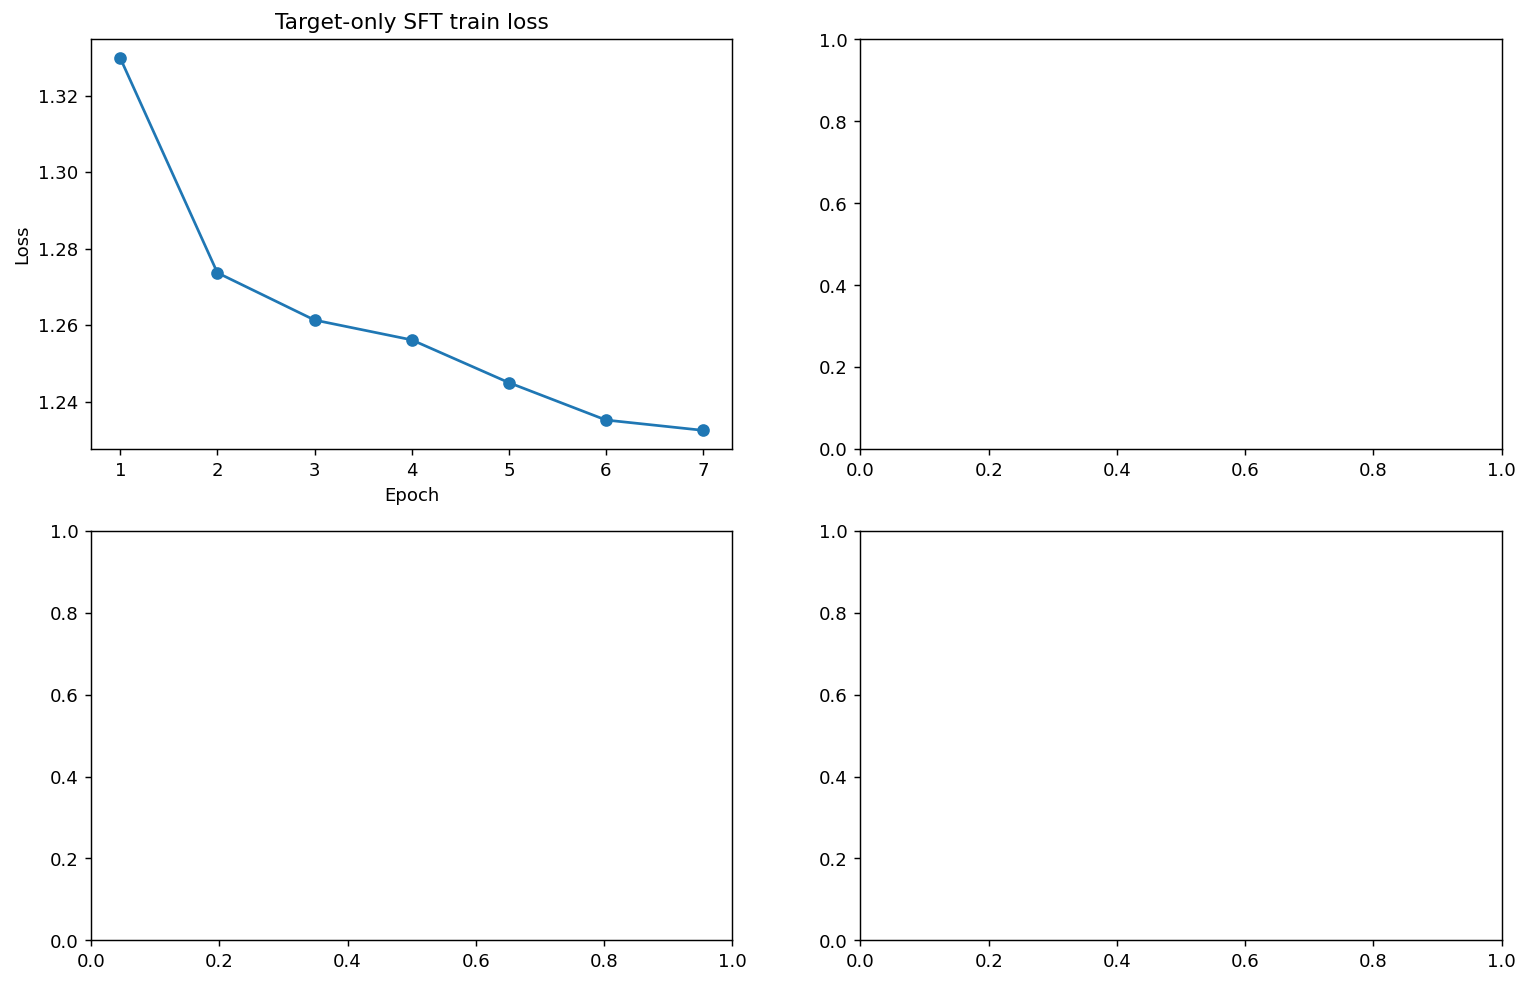

In [15]:
import matplotlib.pyplot as plt

metrics_df = pd.read_json(OUTPUT_DIR / "metrics.json") if (OUTPUT_DIR / "metrics.json").exists() else pd.DataFrame(metrics_log)
if len(metrics_df):
    fig, ax = plt.subplots(figsize=(8, 4), dpi=130)
    ax.plot(metrics_df["epoch"], metrics_df["train_loss"], marker="o")
    ax.set_title("Train+val target-only SFT loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "sft_trainval_loss.png", bbox_inches="tight")
    plt.show()
else:
    print("No metrics yet.")


## 15. Quick inference examples

In [ ]:
def render_prompt(example):
    return tokenizer.decode(example["input_ids"][:example["prompt_length"]], skip_special_tokens=False)

if FINAL_MODEL_DIR.exists():
    print("Final model is ready for external test evaluation.")
else:
    print("Train first.")


## 16. Config snapshot

In [ ]:
config = {
    "run_name": RUN_NAME,
    "base_cpt_dir": str(BASE_CPT_DIR),
    "sid_array_path": str(SID_ARRAY_PATH),
    "task": "next_watched_item_all_ratings_trainval_test",
    "target_only_loss": True,
    "use_dup_suffix": True,
    "max_epochs": MAX_EPOCHS,
    "selected_epochs_from_validation": SELECTED_EPOCHS_FROM_VALIDATION,
    "primary_metric": PRIMARY_METRIC,
    "min_history_len": MIN_HISTORY_LEN,
    "train_history_window_choices": TRAIN_HISTORY_WINDOW_CHOICES,
    "train_window_policy": "single_fixed_window",
    "eval_history_len": EVAL_HISTORY_LEN,
    "max_seq_length": MAX_SEQ_LENGTH,
    "targets_per_user_per_epoch": TARGETS_PER_USER_PER_EPOCH,
    "eval_beam_size": EVAL_BEAM_SIZE,
    "top_k": TOP_K,
    "filter_seen": FILTER_SEEN,
    "seen_filter_scope": SEEN_FILTER_SCOPE,
    "full_test_max_users": FULL_TEST_MAX_USERS,
    "train_source": "train+val",
    "test_context": "train+val",
    "full_finetune": True,
    "lora": False,
    "qlora": False,
    "per_device_batch": PER_DEVICE_BATCH,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "precision": PRECISION_MODE,
}
with (OUTPUT_DIR / "config.json").open("w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
config